In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

orders = pd.DataFrame({
    "order_id": list(range(1, 61)),
    "customer_id": [
        104,102,106,103,102,116,104,104,103,101,
        106,107,104,109,108,101,102,103,104,105,
        106,107,106,109,115,110,103,102,104,104,
        106,109,117,104,114,119,102,103,104,107,
        110,107,108,117,110,118,102,109,104,105,
        106,119,118,109,105,101,102,103,110,111
    ],
    "product": [
        "A","B","A","C","B","A","C","B","A","C",
        "A","B","C","A","B","A","B","C","B","A",
        "C","A","B","C","A","B","C","A","B","C",
        "A","B","C","A","B","C","A","B","C","A",
        "B","C","A","B","C","A","B","C","A","B",
        "C","A","B","C","A","B","C","A","B","C"
    ],
    "price": [
        100,200,100,300,250,100,400,200,None,350,
        120,220,330,140,260,110,210,320,200,300,
        400,150,None,350,100,200,300,None,150,250,
        120,220,330,140,None,110,210,320,200,300,
        400,150,250,350,100,200,300,400,150,250,
        120,220,330,140,260,110,210,None,200,300
    ],
    "quantity": [
        1,2,3,1,2,5,1,3,2,1,
        2,1,3,2,1,4,2,1,3,2,
        1,2,1,3,2,1,2,None,3,2,
        2,1,3,2,1,4,2,1,3,2,
        1,2,1,3,None,1,2,1,3,2,
        2,1,3,2,1,4,2,1,3,2
    ],
    "date": pd.to_datetime([
        "2023-01-01","2023-01-02","2023-01-03","2023-01-04","2023-01-05",
        "2023-01-06","2023-01-07","2023-01-08","2023-01-09","2023-01-10",
        "2023-01-11","2023-01-12","2023-01-13","2023-01-14","2023-01-15",
        "2023-01-16","2023-01-17","2023-01-18","2023-01-19","2023-01-20",
        "2023-01-21","2023-01-22","2023-01-23","2023-01-24","2023-01-25",
        "2023-01-26","2023-01-27","2023-01-28","2023-01-29","2023-01-30",
        "2023-01-31","2023-02-01","2023-02-02","2023-02-03","2023-02-04",
        "2023-02-05","2023-02-06","2023-02-07","2023-02-08","2023-02-09",
        "2023-02-10","2023-02-11","2023-02-12","2023-02-13","2023-02-14",
        "2023-02-15","2023-02-16","2023-02-17","2023-02-18","2023-02-19",
        "2023-02-20","2023-02-21","2023-02-22","2023-02-23","2023-02-24",
        "2023-02-25","2023-02-26","2023-02-27","2023-02-28","2023-03-01"
    ])
})

customers = pd.DataFrame({
    "customer_id": list(range(101, 119)),
    "city": [
        "Yerevan","Gyumri","Vanadzor","Hrazdan","Ijevan","Dilijan","Artashat","Goris",
        "Gyumri","Vanadzor","Hrazdan","Ijevan","Dilijan","Artashat","Goris","Yerevan",
        "Vanadzor","Hrazdan"
    ],
    "signup_date": pd.to_datetime([
        "2022-12-01","2023-01-01","2022-11-15","2023-01-05","2023-01-10","2022-12-20","2023-01-08","2022-11-25",
        "2023-01-12","2022-12-15","2023-01-18","2022-12-28","2023-01-03","2022-11-30","2023-01-06","2022-12-10",
        "2023-01-09","2022-12-22"
    ])
})

In [2]:
orders.head(15)

,order_id,customer_id,product,price,quantity,date
0,1,104,A,100.0,1.0,2023-01-01
1,2,102,B,200.0,2.0,2023-01-02
2,3,106,A,100.0,3.0,2023-01-03
3,4,103,C,300.0,1.0,2023-01-04
4,5,102,B,250.0,2.0,2023-01-05
5,6,116,A,100.0,5.0,2023-01-06
6,7,104,C,400.0,1.0,2023-01-07
7,8,104,B,200.0,3.0,2023-01-08
8,9,103,A,NaN,2.0,2023-01-09
9,10,101,C,350.0,1.0,2023-01-10


In [3]:
orders.shape

(60, 6)

In [4]:
customers

,customer_id,city,signup_date
0,101,Yerevan,2022-12-01
1,102,Gyumri,2023-01-01
2,103,Vanadzor,2022-11-15
3,104,Hrazdan,2023-01-05
4,105,Ijevan,2023-01-10
5,106,Dilijan,2022-12-20
6,107,Artashat,2023-01-08
7,108,Goris,2022-11-25
8,109,Gyumri,2023-01-12
9,110,Vanadzor,2022-12-15


In [5]:
customers.shape

(18, 3)

In [6]:
orders["price"] = orders.groupby("product")["price"].transform(lambda x: x.fillna(x.median()))
orders["quantity"] = orders["quantity"].fillna(orders.quantity.median())

In [7]:
df = orders.merge(customers, on="customer_id", how="left")

df["total_amount"] = df["price"] * df["quantity"]

df["days_since_signup"] = (
    df["date"] - df["signup_date"]
).dt.days

df.head(15)

,order_id,customer_id,product,price,quantity,date,city,signup_date,total_amount,days_since_signup
0,1,104,A,100.0,1.0,2023-01-01,Hrazdan,2023-01-05,100.0,-4.0
1,2,102,B,200.0,2.0,2023-01-02,Gyumri,2023-01-01,400.0,1.0
2,3,106,A,100.0,3.0,2023-01-03,Dilijan,2022-12-20,300.0,14.0
3,4,103,C,300.0,1.0,2023-01-04,Vanadzor,2022-11-15,300.0,50.0
4,5,102,B,250.0,2.0,2023-01-05,Gyumri,2023-01-01,500.0,4.0
5,6,116,A,100.0,5.0,2023-01-06,Yerevan,2022-12-10,500.0,27.0
6,7,104,C,400.0,1.0,2023-01-07,Hrazdan,2023-01-05,400.0,2.0
7,8,104,B,200.0,3.0,2023-01-08,Hrazdan,2023-01-05,600.0,3.0
8,9,103,A,145.0,2.0,2023-01-09,Vanadzor,2022-11-15,290.0,55.0
9,10,101,C,350.0,1.0,2023-01-10,Yerevan,2022-12-01,350.0,40.0


In [8]:
df.shape

(60, 10)

In [9]:
df = df[(df["total_amount"] > 350) & (df["days_since_signup"] >= 1)]
df.head(10)

,order_id,customer_id,product,price,quantity,date,city,signup_date,total_amount,days_since_signup
1,2,102,B,200.0,2.0,2023-01-02,Gyumri,2023-01-01,400.0,1.0
4,5,102,B,250.0,2.0,2023-01-05,Gyumri,2023-01-01,500.0,4.0
5,6,116,A,100.0,5.0,2023-01-06,Yerevan,2022-12-10,500.0,27.0
6,7,104,C,400.0,1.0,2023-01-07,Hrazdan,2023-01-05,400.0,2.0
7,8,104,B,200.0,3.0,2023-01-08,Hrazdan,2023-01-05,600.0,3.0
12,13,104,C,330.0,3.0,2023-01-13,Hrazdan,2023-01-05,990.0,8.0
15,16,101,A,110.0,4.0,2023-01-16,Yerevan,2022-12-01,440.0,46.0
16,17,102,B,210.0,2.0,2023-01-17,Gyumri,2023-01-01,420.0,16.0
18,19,104,B,200.0,3.0,2023-01-19,Hrazdan,2023-01-05,600.0,14.0
19,20,105,A,300.0,2.0,2023-01-20,Ijevan,2023-01-10,600.0,10.0


In [10]:
df.shape

(30, 10)

In [11]:
df.describe()

,order_id,customer_id,price,quantity,date,signup_date,total_amount,days_since_signup
count,30.000000,30.000000,30.000000,30.000000,30,30,30.000000,30.000000
mean,31.900000,106.300000,259.666667,2.466667,2023-01-31 21:36:00,2022-12-29 12:00:00,583.666667,33.400000
min,2.000000,101.000000,100.000000,1.000000,2023-01-02 00:00:00,2022-11-15 00:00:00,400.000000,1.000000
25%,17.500000,102.250000,200.000000,2.000000,2023-01-17 12:00:00,2022-12-24 12:00:00,425.000000,14.500000
50%,31.500000,104.000000,250.000000,2.000000,2023-01-31 12:00:00,2023-01-05 00:00:00,500.000000,33.000000
75%,47.750000,109.000000,330.000000,3.000000,2023-02-16 18:00:00,2023-01-07 06:00:00,600.000000,45.500000
max,60.000000,118.000000,400.000000,5.000000,2023-03-01 00:00:00,2023-01-18 00:00:00,1050.000000,86.000000
std,18.096199,5.079709,90.572255,0.937102,NaN,NaN,210.639148,22.713508


In [12]:
df.groupby("city")["total_amount"].agg(["sum", "mean", "count"])

,sum,mean,count
city,,,
Artashat,600.0,600.00,1
Dilijan,400.0,400.00,1
Gyumri,4210.0,526.25,8
Hrazdan,6180.0,618.00,10
Ijevan,1100.0,550.00,2
Vanadzor,3640.0,728.00,5
Yerevan,1380.0,460.00,3


In [13]:
cust_sum = df.groupby("customer_id")["total_amount"].sum()
cust_sum

customer_id
101     880.0
102    2760.0
103     600.0
104    4590.0
105    1100.0
106     400.0
107     600.0
109    1450.0
110    1000.0
111     600.0
116     500.0
117    2040.0
118     990.0
Name: total_amount, dtype: float64

In [14]:
top5 = cust_sum.nlargest(5).sort_index()
top5

customer_id
102    2760.0
104    4590.0
105    1100.0
109    1450.0
117    2040.0
Name: total_amount, dtype: float64

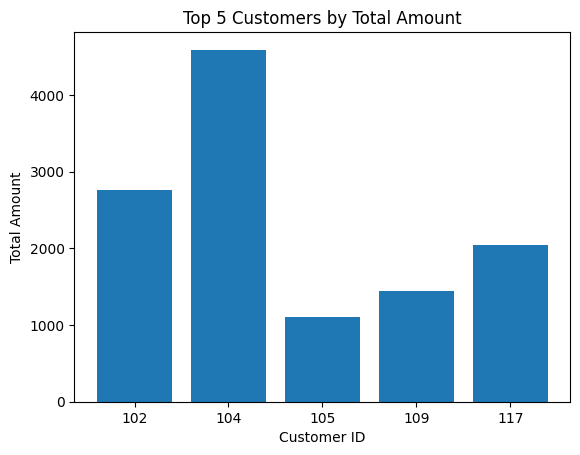

In [15]:
plt.bar(top5.index.astype(str), top5.values)
plt.xlabel("Customer ID")
plt.ylabel("Total Amount")
plt.title("Top 5 Customers by Total Amount")
plt.show()

In [16]:
df.sort_values(by = "customer_id")

,order_id,customer_id,product,price,quantity,date,city,signup_date,total_amount,days_since_signup
55,56,101,B,110.0,4.0,2023-02-25,Yerevan,2022-12-01,440.0,86.0
15,16,101,A,110.0,4.0,2023-01-16,Yerevan,2022-12-01,440.0,46.0
1,2,102,B,200.0,2.0,2023-01-02,Gyumri,2023-01-01,400.0,1.0
4,5,102,B,250.0,2.0,2023-01-05,Gyumri,2023-01-01,500.0,4.0
56,57,102,C,210.0,2.0,2023-02-26,Gyumri,2023-01-01,420.0,56.0
46,47,102,B,300.0,2.0,2023-02-16,Gyumri,2023-01-01,600.0,46.0
16,17,102,B,210.0,2.0,2023-01-17,Gyumri,2023-01-01,420.0,16.0
36,37,102,A,210.0,2.0,2023-02-06,Gyumri,2023-01-01,420.0,36.0
26,27,103,C,300.0,2.0,2023-01-27,Vanadzor,2022-11-15,600.0,73.0
48,49,104,A,150.0,3.0,2023-02-18,Hrazdan,2023-01-05,450.0,44.0


In [17]:
df["customer_id"].value_counts().idxmax()

np.int64(104)

In [18]:
df["behavior"] = np.where(
    df.groupby("customer_id")["order_id"].transform("count") > 1,
    "returning",
    "new"
)
df

,order_id,customer_id,product,price,quantity,date,city,signup_date,total_amount,days_since_signup,behavior
1,2,102,B,200.0,2.0,2023-01-02,Gyumri,2023-01-01,400.0,1.0,returning
4,5,102,B,250.0,2.0,2023-01-05,Gyumri,2023-01-01,500.0,4.0,returning
5,6,116,A,100.0,5.0,2023-01-06,Yerevan,2022-12-10,500.0,27.0,new
6,7,104,C,400.0,1.0,2023-01-07,Hrazdan,2023-01-05,400.0,2.0,returning
7,8,104,B,200.0,3.0,2023-01-08,Hrazdan,2023-01-05,600.0,3.0,returning
12,13,104,C,330.0,3.0,2023-01-13,Hrazdan,2023-01-05,990.0,8.0,returning
15,16,101,A,110.0,4.0,2023-01-16,Yerevan,2022-12-01,440.0,46.0,returning
16,17,102,B,210.0,2.0,2023-01-17,Gyumri,2023-01-01,420.0,16.0,returning
18,19,104,B,200.0,3.0,2023-01-19,Hrazdan,2023-01-05,600.0,14.0,returning
19,20,105,A,300.0,2.0,2023-01-20,Ijevan,2023-01-10,600.0,10.0,returning


In [19]:
city_mean = df.groupby("city")["total_amount"].mean()
city_mean

city
Artashat    600.00
Dilijan     400.00
Gyumri      526.25
Hrazdan     618.00
Ijevan      550.00
Vanadzor    728.00
Yerevan     460.00
Name: total_amount, dtype: float64

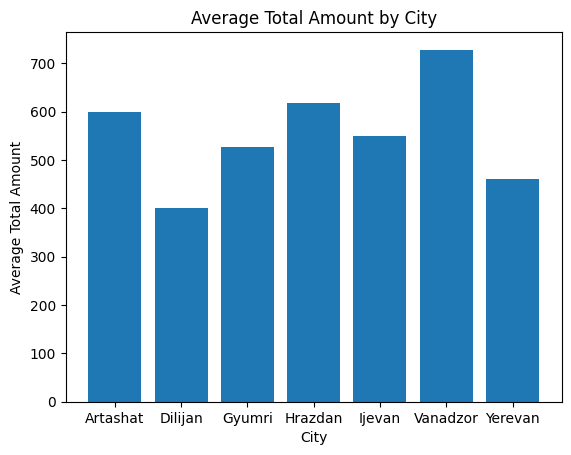

In [20]:
plt.bar(city_mean.index, city_mean.values)
plt.xlabel("City")
plt.ylabel("Average Total Amount")
plt.title("Average Total Amount by City")
plt.show()

In [21]:
avg_product = df.groupby("product")["total_amount"].mean().round(2)
avg_product

product
A    501.67
B    580.77
C    631.82
Name: total_amount, dtype: float64

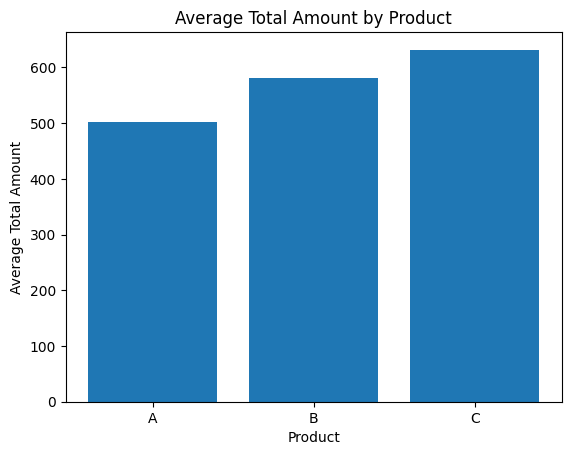

In [22]:
plt.bar(avg_product.index, avg_product.values)
plt.xlabel("Product")
plt.ylabel("Average Total Amount")
plt.title("Average Total Amount by Product")
plt.show()